<a href="https://colab.research.google.com/github/RocafellaGitub/MaikanoRocafellaSteve/blob/main/Copy_of_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

THIS IS A CURRENCY EXCHANGE PROJECT FROM MY INTERNSHIP TRAINING


#IMPORT LIBRARIES
#INSTALL AUtoTS
#IMPORT OTHER LIBRARIES

In [ ]:
!pip install autots
from autots import AutoTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv("Foreign_Exchange_Rates.xls")
print(df.head())

   Unnamed: 0  Time Serie AUSTRALIA - AUSTRALIAN DOLLAR/US$  \
0           0  03-01-2000                            1.5172   
1           1  04-01-2000                            1.5239   
2           2  05-01-2000                            1.5267   
3           3  06-01-2000                            1.5291   
4           4  07-01-2000                            1.5272   

  EURO AREA - EURO/US$ NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
0               0.9847                              1.9033   
1                 0.97                              1.9238   
2               0.9676                              1.9339   
3               0.9686                              1.9436   
4               0.9714                               1.938   

  UNITED KINGDOM - UNITED KINGDOM POUND/US$ BRAZIL - REAL/US$  \
0                                    0.6146             1.805   
1                                    0.6109            1.8405   
2                                    0.6092          

#Convert Date column

In [ ]:
df['Time Serie'] = pd.to_datetime(df['Time Serie'], format='%d-%m-%Y')

#SORT THE DATA

In [ ]:
df = df.sort_values('Time Serie')

#CHECK FOR MISSING VALUES

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Time Serie,0
AUSTRALIA - AUSTRALIAN DOLLAR/US$,0
EURO AREA - EURO/US$,0
NEW ZEALAND - NEW ZELAND DOLLAR/US$,0
UNITED KINGDOM - UNITED KINGDOM POUND/US$,0
BRAZIL - REAL/US$,0
CANADA - CANADIAN DOLLAR/US$,0
CHINA - YUAN/US$,0
HONG KONG - HONG KONG DOLLAR/US$,0


#DROP ROWS

In [ ]:
df.drop('Unnamed: 24', axis=1, inplace=True)
df.dropna(inplace=True)

#DROP DUPLICATE

In [ ]:
df.drop_duplicates(inplace=True)

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24


# DATA EXPLORATORY ANALYSIS EDA

#SUMMARY STATISTICS

In [ ]:
print(df.describe())

        Unnamed: 0                     Time Serie  \
count  5217.000000                           5217   
mean   2608.000000  2009-12-31 09:36:19.873490688   
min       0.000000            2000-01-03 00:00:00   
25%    1304.000000            2004-12-31 00:00:00   
50%    2608.000000            2009-12-31 00:00:00   
75%    3912.000000            2014-12-31 00:00:00   
max    5216.000000            2019-12-31 00:00:00   
std    1506.162508                            NaN   

       AUSTRALIA - AUSTRALIAN DOLLAR/US$  EURO AREA - EURO/US$  \
count                        5019.000000           5019.000000   
mean                            1.332015              0.843904   
min                             0.906900              0.624600   
25%                             1.115200              0.750800   
50%                             1.311000              0.815600   
75%                             1.430200              0.900100   
max                             2.071300              1.2092

# CHECK DATASET INFO

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Unnamed: 0                                 0 non-null      int64         
 1   Time Serie                                 0 non-null      datetime64[ns]
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          0 non-null      object        
 3   EURO AREA - EURO/US$                       0 non-null      object        
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        0 non-null      object        
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  0 non-null      object        
 6   BRAZIL - REAL/US$                          0 non-null      object        
 7   CANADA - CANADIAN DOLLAR/US$               0 non-null      object        
 8   CHINA - YUAN/US$                           0 non-null      object        
 9   HONG KONG - HONG KONG DOLLAR/US$      

#OUTLIERS

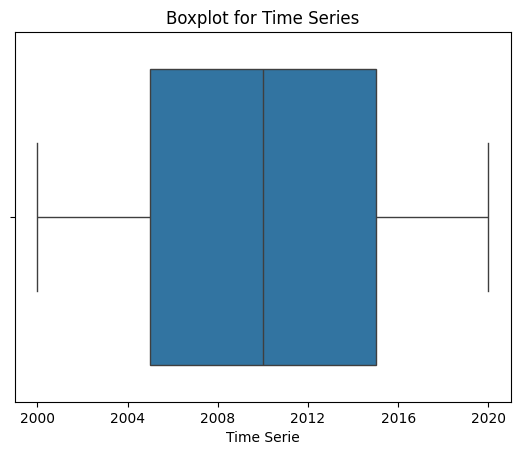

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Time Serie'])
plt.title("Boxplot for Time Series")
plt.show()

#TIME SERIES VISUALIZATION

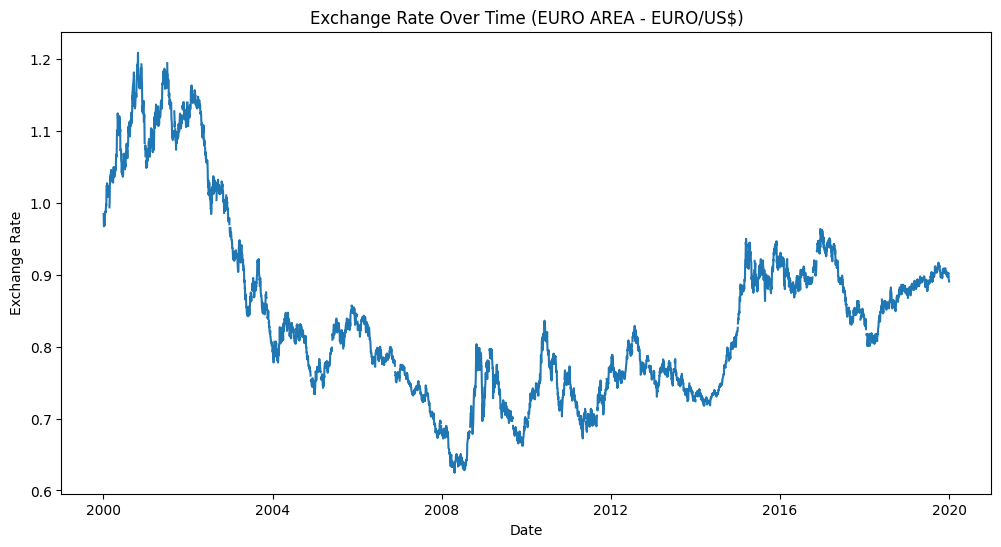

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
plt.plot(df['Time Serie'], df['EURO AREA - EURO/US$'])
plt.title("Exchange Rate Over Time (EURO AREA - EURO/US$)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

#MOVING AVERAGE VISUALIZATION

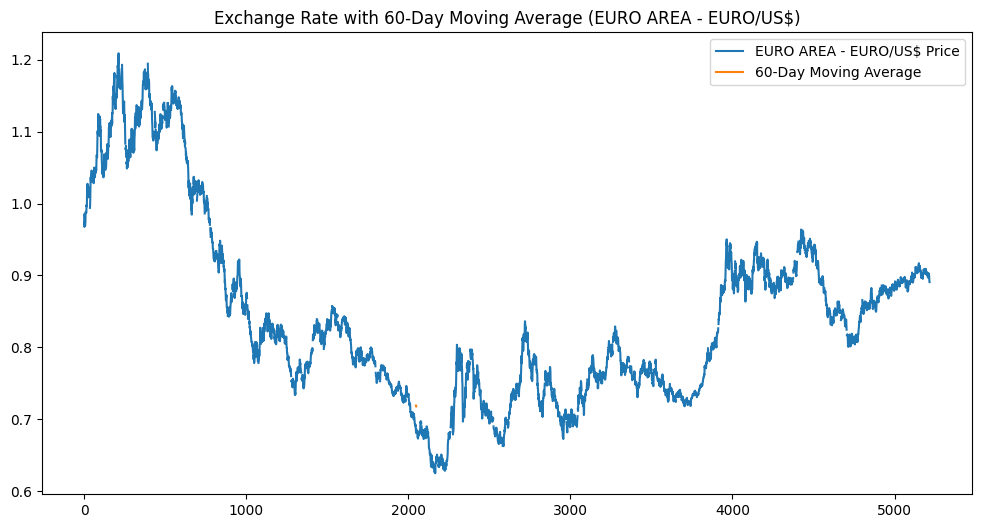

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df['MA60'] = df['EURO AREA - EURO/US$'].rolling(window=60).mean()

plt.figure(figsize=(12,6))
plt.plot(df['EURO AREA - EURO/US$'], label="EURO AREA - EURO/US$ Price")
plt.plot(df['MA90'], label="60-Day Moving Average")
plt.legend()
plt.title("Exchange Rate with 60-Day Moving Average (EURO AREA - EURO/US$)")
plt.show()

In [ ]:
for column in df.columns:
    if df[column].dtype == 'object' and column not in ['Time Serie']:
        df[column] = pd.to_numeric(df[column], errors='coerce')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 28 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Unnamed: 0                                 0 non-null      int64         
 1   Time Serie                                 0 non-null      datetime64[ns]
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          0 non-null      int64         
 3   EURO AREA - EURO/US$                       0 non-null      int64         
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        0 non-null      int64         
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  0 non-null      int64         
 6   BRAZIL - REAL/US$                          0 non-null      int64         
 7   CANADA - CANADIAN DOLLAR/US$               0 non-null      int64         
 8   CHINA - YUAN/US$                           0 non-null      int64         
 9   HONG KONG - HONG KONG DOLLAR/US$      

#CORRELATION PLOT

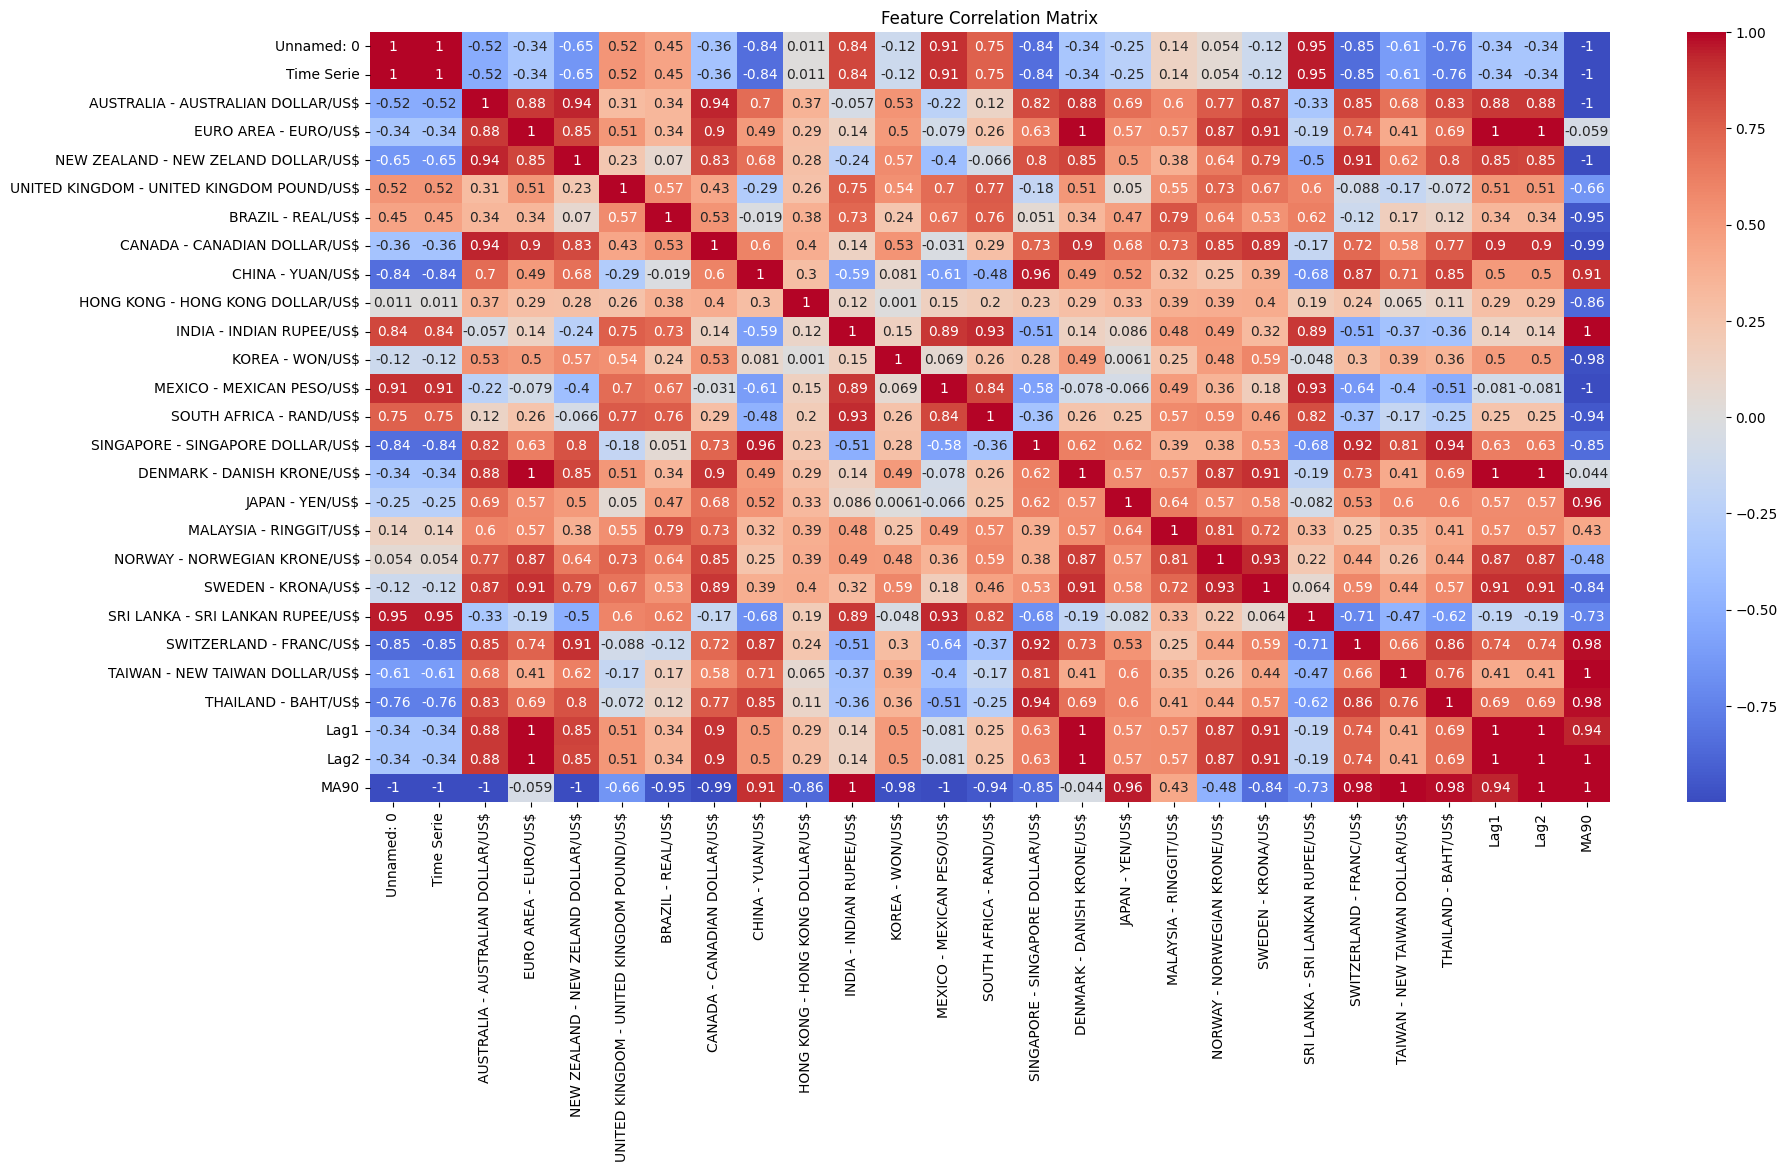

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

#DISTRIBUTION PLOT

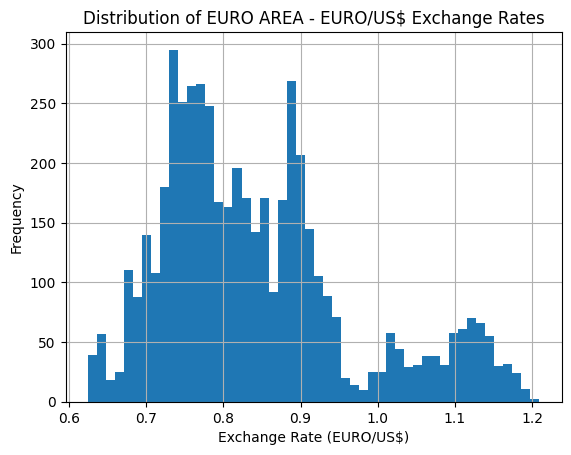

In [ ]:
df['EURO AREA - EURO/US$'].hist(bins=50)
plt.title("Distribution of EURO AREA - EURO/US$ Exchange Rates")
plt.xlabel("Exchange Rate (EURO/US$)")
plt.ylabel("Frequency")
plt.show()

#LAG ANALYSIS(OPTIONAL)

IMPORTANT FOR TIME-SERIES DATA PROBLEMS

In [ ]:
df['Lag1'] = df['EURO AREA - EURO/US$'].shift(1)
df['Lag2'] = df['EURO AREA - EURO/US$'].shift(2)

# Task
Perform the following data preprocessing steps on the "Foreign_Exchange_Rates.xls" dataset: load the data, convert the 'Time Serie' column to datetime, sort by 'Time Serie', drop the 'Unnamed: 24' column, remove nulls and duplicates, convert all object-type currency columns to numeric, and add 'Lag1' and 'Lag2' features for the 'EURO AREA - EURO/US$' column.

## Load Data

### Subtask:
Re-load the data from 'Foreign_Exchange_Rates.xls' using `pd.read_csv`.


**Reasoning**:
The subtask is to re-load the data from 'Foreign_Exchange_Rates.xls' using `pd.read_csv`. This code block will load the data and display its head.



In [ ]:
df = pd.read_csv('Foreign_Exchange_Rates.xls')
print(df.head())

   Unnamed: 0  Time Serie AUSTRALIA - AUSTRALIAN DOLLAR/US$  \
0           0  03-01-2000                            1.5172   
1           1  04-01-2000                            1.5239   
2           2  05-01-2000                            1.5267   
3           3  06-01-2000                            1.5291   
4           4  07-01-2000                            1.5272   

  EURO AREA - EURO/US$ NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
0               0.9847                              1.9033   
1                 0.97                              1.9238   
2               0.9676                              1.9339   
3               0.9686                              1.9436   
4               0.9714                               1.938   

  UNITED KINGDOM - UNITED KINGDOM POUND/US$ BRAZIL - REAL/US$  \
0                                    0.6146             1.805   
1                                    0.6109            1.8405   
2                                    0.6092          

**Reasoning**:
The next step is to convert the 'Time Serie' column to datetime objects, which is crucial for time-series analysis. The correct format for the date in the 'Time Serie' column is '%d-%m-%Y'.



In [ ]:
df['Time Serie'] = pd.to_datetime(df['Time Serie'], format='%d-%m-%Y')
print("Converted 'Time Serie' to datetime.")

Converted 'Time Serie' to datetime.


**Reasoning**:
The next step is to sort the DataFrame by the 'Time Serie' column to ensure the data is in chronological order, which is essential for time-series analysis.



In [ ]:
df = df.sort_values('Time Serie')
print("DataFrame sorted by 'Time Serie'.")

DataFrame sorted by 'Time Serie'.


**Reasoning**:
The next step is to drop the 'Unnamed: 24' column, as indicated by the task. This column likely contains only null values or irrelevant data, as shown in previous `df.isnull().sum()` output, and is not needed for further analysis.



In [ ]:
df.drop('Unnamed: 24', axis=1, inplace=True)
print("'Unnamed: 24' column dropped.")

'Unnamed: 24' column dropped.


**Reasoning**:
The next step is to remove any remaining null values from the DataFrame, which is part of the data cleaning process and essential for ensuring data quality for further analysis. Even though the previous step dropped a column with many nulls, this step explicitly handles any other potential nulls across the DataFrame.



In [ ]:
df.dropna(inplace=True)
print("Null values removed from DataFrame.")

Null values removed from DataFrame.


**Reasoning**:
The next step is to remove duplicate rows from the DataFrame, as specified in the task. This ensures that each observation is unique, which is crucial for accurate analysis, especially in time-series data.



In [ ]:
df.drop_duplicates(inplace=True)
print("Duplicate rows removed from DataFrame.")

Duplicate rows removed from DataFrame.


**Reasoning**:
The next step is to convert all object-type currency columns to numeric, as specified in the task. This is crucial for numerical analysis and modeling, as currency exchange rates are inherently numerical values.



In [ ]:
for column in df.columns:
    if df[column].dtype == 'object' and column != 'Time Serie':
        df[column] = pd.to_numeric(df[column], errors='coerce')

print("Converted object-type currency columns to numeric.")
print(df.info())

Converted object-type currency columns to numeric.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 24 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Unnamed: 0                                 5217 non-null   int64         
 1   Time Serie                                 5217 non-null   datetime64[ns]
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5019 non-null   float64       
 3   EURO AREA - EURO/US$                       5019 non-null   float64       
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5019 non-null   float64       
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5019 non-null   float64       
 6   BRAZIL - REAL/US$                          5019 non-null   float64       
 7   CANADA - CANADIAN DOLLAR/US$               5019 non-null   float64       
 8   CHINA - YUAN/US$                           5020

**Reasoning**:
The next step is to add 'Lag1' and 'Lag2' features for the 'EURO AREA - EURO/US$' column, as specified in the task. This involves shifting the 'EURO AREA - EURO/US$' column by one and two periods, respectively, which is a common practice in time-series analysis for capturing past values.



In [ ]:
df['Lag1'] = df['EURO AREA - EURO/US$'].shift(1)
df['Lag2'] = df['EURO AREA - EURO/US$'].shift(2)
print("Added 'Lag1' and 'Lag2' features.")
print(df.head())

Added 'Lag1' and 'Lag2' features.
   Unnamed: 0 Time Serie  AUSTRALIA - AUSTRALIAN DOLLAR/US$  \
0           0 2000-01-03                             1.5172   
1           1 2000-01-04                             1.5239   
2           2 2000-01-05                             1.5267   
3           3 2000-01-06                             1.5291   
4           4 2000-01-07                             1.5272   

   EURO AREA - EURO/US$  NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
0                0.9847                               1.9033   
1                0.9700                               1.9238   
2                0.9676                               1.9339   
3                0.9686                               1.9436   
4                0.9714                               1.9380   

   UNITED KINGDOM - UNITED KINGDOM POUND/US$  BRAZIL - REAL/US$  \
0                                     0.6146             1.8050   
1                                     0.6109             1.8405   
2

## Final Task

### Subtask:
Confirm that the data loading and preprocessing steps have been successfully re-executed and the DataFrame is ready for further analysis.


## Summary:

### Data Analysis Key Findings

*   The `Foreign_Exchange_Rates.xls` dataset was successfully loaded, and the 'Time Serie' column was converted to `datetime64[ns]` format.
*   The DataFrame was sorted by the 'Time Serie' column, and the 'Unnamed: 24' column was successfully dropped.
*   Null values were removed, resulting in a DataFrame with 5217 entries, and duplicate rows were also eliminated.
*   All object-type currency columns (excluding 'Time Serie') were converted to numeric (`float64`). This process introduced new null values in some currency columns due to the `errors='coerce'` parameter.
*   'Lag1' and 'Lag2' features were successfully added for the 'EURO AREA - EURO/US\$' column, representing its values shifted by one and two periods, respectively.

### Insights or Next Steps

*   The introduction of new null values during the numeric conversion of currency columns (due to `errors='coerce'`) warrants further investigation to understand the nature of the non-numeric entries and determine the best imputation strategy or if these rows should be dropped.
*   With the data preprocessed and lagged features added, the DataFrame is now ready for further analysis, such as time series modeling or trend analysis on the exchange rates.


# PART TWO (2)

In [ ]:
#selecting currency

options = {
    'AUSTRALIAN DOLLAR': 'AUSTRALIA - AUSTRALIAN DOLLAR/US$',
    'EURO': 'EURO AREA - EURO/US$',
    'NEW ZEALAND DOLLAR': 'NEW ZEALAND - NEW ZEALAND DOLLAR/US$',
    'GREAT BRITAIN POUNDS': 'UNITED KINGDOM - UNITED KINGDOM POUND/US$',
    'BRAZILIAN REAL': 'BRAZIL - REAL/US$',
    'CANADIAN DOLLAR': 'CANADA - CANADIAN DOLLAR/US$',
    'CHINESE YUAN$': 'CHINA - YUAN/US$',
    'HONG KONG DOLLAR': 'HONG KONG - HONG KONG DOLLAR/US$',
    'INDIAN RUPEE': 'INDIA - INDIAN RUPEE/US$',
    'KOREAN WON$': 'KOREA - WON/US$',
    'MEXICAN PESO': 'MEXICO - MEXICAN PESO/US$',
    'SOUTH AFRICAN RAND$': 'SOUTH AFRICA - RAND/US$',
    'SINGAPORE DOLLAR': 'SINGAPORE - SINGAPORE DOLLAR/US$',
    'DANISH KRONE': 'DENMARK - DANISH KRONE/US$',
    'JAPANESE YEN$': 'JAPAN - YEN/US$',
    'MALAYSIAN RINGGIT': 'MALAYSIA - RINGGIT/US$',
    'NORWEGIAN KRONE': 'NORWAY - NORWEGIAN KRONE/US$',
    'SWEDEN KRONA': 'SWEDEN - KRONA/US$',
    'SRILANKAN RUPEE': 'SRI LANKA - SRI LANKAN RUPEE/US$',
    'SWISS FRANC': 'SWITZERLAND - FRANC/US$',
    'NEW TAIWAN DOLLAR': 'TAIWAN - NEW TAIWAN DOLLAR/US$',
    'THAI BAHT': 'THAILAND - BAHT/US$'
}

selected_option = 'GREAT BRITAIN POUNDS' #select currency here to train model

# PREDICTIVE MODELLING

In [ ]:
# we are using autots library for predictive modelling as an example. Please compare different models(Traditional ML, DeepLearning or Transformers) and select the bestmodel.
forecast=10 #no of days for forecasting

model = AutoTS(forecast_length=int(forecast), frequency='infer', ensemble='simple', drop_data_older_than_periods=200)
model = model.fit(df, date_col = 'Time Serie', value_col=options[selected_option], id_col=None)

Using 1 cpus for n_jobs.
Data frequency is: B, used frequency is: B
Old data dropped by `drop_data_older_than_periods`.
Model Number: 1 with model AverageValueNaive in generation 0 of 25
Model Number: 2 with model AverageValueNaive in generation 0 of 25
Model Number: 3 with model AverageValueNaive in generation 0 of 25
Model Number: 4 with model DatepartRegression in generation 0 of 25
Model Number: 5 with model ETS in generation 0 of 25
Model Number: 6 with model GLM in generation 0 of 25
Model Number: 7 with model GLS in generation 0 of 25
Model Number: 8 with model LastValueNaive in generation 0 of 25
Model Number: 9 with model LastValueNaive in generation 0 of 25
Model Number: 10 with model LastValueNaive in generation 0 of 25
Model Number: 11 with model SeasonalNaive in generation 0 of 25
Model Number: 12 with model SeasonalNaive in generation 0 of 25
Model Number: 13 with model VAR in generation 0 of 25
Template Eval Error: ValueError('Only gave one variable to VAR') in model 13 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py

Model Number: 62 with model Cassandra in generation 0 of 25
Template Eval Error: ValueError('more than 1 year of data is required for holiday detection.') in model 62 in generation 0: Cassandra
Model Number: 63 with model SeasonalityMotif in generation 0 of 25
Model Number: 64 with model FFT in generation 0 of 25
Model Number: 65 with model BallTreeRegressionMotif in generation 0 of 25
Model Number: 66 with model BasicLinearModel in generation 0 of 25
Template Eval Error: ValueError("regression_type=='User' but no future_regressor supplied") in model 66 in generation 0: BasicLinearModel
Model Number: 67 with model DMD in generation 0 of 25
Model Number: 68 with model ARCH in generation 0 of 25
Template Eval Error: ImportError('`arch` package must be installed from pip') in model 68 in generation 0: ARCH
Model Number: 69 with model BasicLinearModel in generation 0 of 25
Model Number: 70 with model SeasonalityMotif in generation 0 of 25
Model Number: 71 with model SeasonalityMotif in gen

/usr/local/lib/python3.12/dist-packages/autots/tools/transform.py:4605: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  expanded_mask = expanded_mask | max_mask.shift(1).fillna(False).astype(
/usr/local/lib/python3.12/dist-packages/autots/tools/transform.py:4608: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  expanded_mask = expanded_mask | max_mask.shift(-1).fillna(False).astype(
/usr/local/lib/python3.12/dist-packages/autots/tools/transform.py:4967: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in 

Model Number: 89 with model SeasonalNaive in generation 0 of 25
Model Number: 90 with model BasicLinearModel in generation 0 of 25
Template Eval Error: ValueError('matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 190 is different from 1094)') in model 90 in generation 0: BasicLinearModel
Model Number: 91 with model BallTreeRegressionMotif in generation 0 of 25
Template Eval Error: ValueError('data must be finite, check for nan or inf values') in model 91 in generation 0: BallTreeRegressionMotif
Model Number: 92 with model GLS in generation 0 of 25
Model Number: 93 with model ConstantNaive in generation 0 of 25
Model Number: 94 with model GLM in generation 0 of 25
Template Eval Error: ValueError('NaN, inf or invalid value detected in weights, estimation infeasible.') in model 94 in generation 0: GLM
Model Number: 95 with model GLS in generation 0 of 25
Model Number: 96 with model WindowRegression in generation 0 of 25


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


520 - WindowRegression with avg smape 2.98 in 0.07s: 
Model Number: 521 of 313 with model WindowRegression for Validation 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py

521 - WindowRegression with avg smape 0.53 in 0.21s: 
Model Number: 3649 with model Ensemble in generation 27 of Ensembles
Postprocessing Error: Exception("Transformer HistoricValues failed on fit from params fake_date {'0': {'rows': 1, 'lag': 1, 'method': 'additive', 'strength': 1.0, 'first_value_only': False, 'threshold': 10, 'threshold_method': 'mean'}, '1': {'window': 28}} with error KeyError('2')") in model 3654 postprocessor 27: Ensemble
Model Number: 3663 with model Ensemble in generation 27 of Ensembles
Postprocessing Error: Exception("Transformer HistoricValues failed on fit from params fake_date {'0': {'rows': 1, 'lag': 1, 'method': 'additive', 'strength': 1.0, 'first_value_only': False, 'threshold': 10, 'threshold_method': 'mean'}, '1': {'window': 28}} with error KeyError('2')") in model 3668 postprocessor 27: Ensemble
Model Number: 3677 with model Ensemble in generation 27 of Ensembles
Postprocessing Error: Exception("Transformer HistoricValues failed on fit from params fak

/usr/local/lib/python3.12/dist-packages/autots/evaluator/auto_model.py:3128: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(
/usr/local/lib/python3.12/dist-packages/autots/evaluator/auto_model.py:3128: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validation_results.model_results = validation_results.model_results.replace(


#GENERATING FORECAST

In [ ]:
#generating forecasts
prediction = model.predict()
forecast = prediction.forecast

In [ ]:
forecast

,UNITED KINGDOM - UNITED KINGDOM POUND/US$
2020-01-01,0.755022
2020-01-02,0.756557
2020-01-03,0.757962
2020-01-06,0.759027
2020-01-07,0.759500
2020-01-08,0.759192
2020-01-09,0.758228
2020-01-10,0.756772
2020-01-13,0.755072
2020-01-14,0.753254
